In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
rho = 1
mu = 1
u_in = 1
D = 1
L = 2

In [3]:
geom = dde.geometry.Rectangle(xmin=[-L/2, -D/2], xmax=[L/2, D/2])

In [4]:
def boundary_wall(X, on_boundary):
    return on_boundary and (
        np.isclose(X[1], -D/2, rtol=1e-5, atol=1e-8) or
        np.isclose(X[1],  D/2, rtol=1e-5, atol=1e-8)
    )

def boundary_inlet(X, on_boundary):
    return on_boundary and np.isclose(X[0], -L/2, rtol=1e-5, atol=1e-8)

def boundary_outlet(X, on_boundary):
    return on_boundary and np.isclose(X[0], L/2, rtol=1e-5, atol=1e-8)

In [5]:
bc_wall_u = dde.DirichletBC(geom, lambda X:0., boundary_wall, component= 0)
bc_wall_v = dde.DirichletBC(geom, lambda X:0., boundary_wall, component= 1)

bc_inlet_u = dde.DirichletBC(geom, lambda X:u_in, boundary_inlet, component= 0)
bc_inlet_v = dde.DirichletBC(geom, lambda X:0.   , boundary_inlet, component= 1)

bc_outlet_p = dde.DirichletBC(geom, lambda X:0.  , boundary_outlet, component= 2)
bc_outlet_v = dde.DirichletBC(geom, lambda X:0.  , boundary_outlet, component= 1)

In [6]:
def pde(X,Y):
    du_x =dde.grad.jacobian(Y, X, i=0, j=0)
    du_y =dde.grad.jacobian(Y, X, i=0, j=1)
    dv_x =dde.grad.jacobian(Y, X, i=1, j=0)
    dv_y =dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x =dde.grad.jacobian(Y, X, i=2, j=0)
    dp_y =dde.grad.jacobian(Y, X, i=2, j=1)
    
    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)

    u = Y[:, 0].reshape(-1, 1)
    v = Y[:, 1].reshape(-1, 1)
    
    pde_u = u * du_x + v * du_y + (1/rho) * dp_x - (mu/rho) * (du_xx + du_yy)
    pde_v = u * dv_x + v * dv_y + (1/rho) * dp_y - (mu/rho) * (dv_xx + dv_yy)
    pde_cont = du_x + dv_y
    
    return [pde_u,pde_v,pde_cont]

In [7]:
data = dde.data.PDE(geom,
                   pde,
                   [bc_wall_u,bc_wall_v,bc_inlet_u,bc_inlet_v,bc_outlet_p,bc_outlet_v],
                   num_domain  = 2000,
                   num_boundary= 200,
                   num_test = 200)

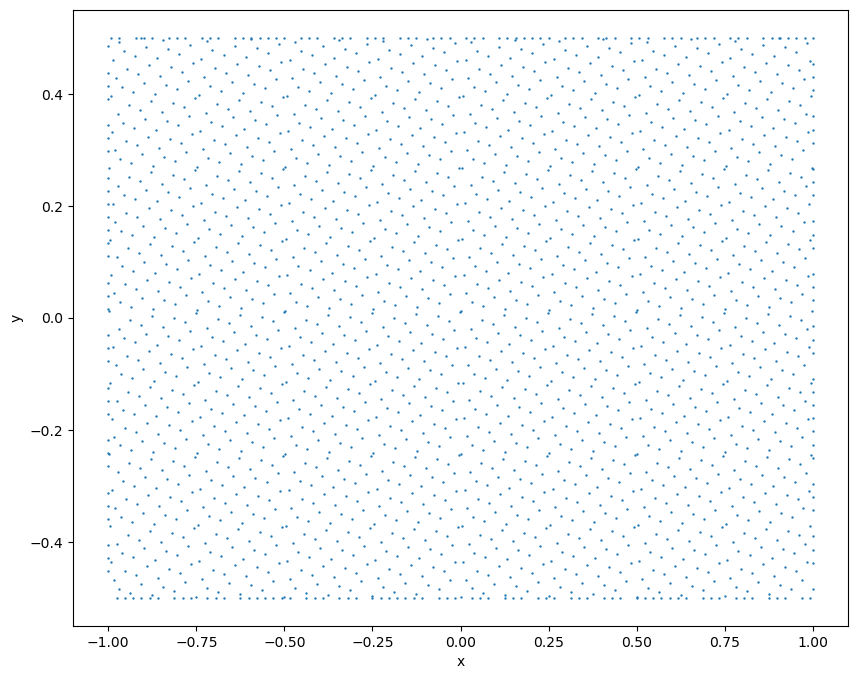

In [8]:
plt.figure(figsize=(10,8))
plt.scatter(data.train_x_all[:,0], data.train_x_all[:,1], s= 0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [9]:
net = dde.maps.FNN([2] + [64]*5 + [3] , "tanh", "Glorot uniform")

In [10]:
model = dde.Model(data, net)
model.compile("adam",lr=1e-3)

Compiling model...
'compile' took 0.001196 s



In [11]:
losshistory, train_state = model.train(epochs = 10000)

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [1.57e-02, 1.11e-01, 7.65e-04, 1.59e-02, 2.57e-02, 1.26e+00, 6.71e-02, 7.66e-03, 6.63e-02]    [1.36e-02, 1.13e-01, 6.54e-04, 1.59e-02, 2.57e-02, 1.26e+00, 6.71e-02, 7.66e-03, 6.63e-02]    []  
1000      [8.77e-04, 6.73e-04, 8.95e-03, 2.92e-02, 1.42e-02, 3.76e-02, 2.78e-03, 6.80e-04, 1.65e-05]    [5.48e-04, 3.90e-04, 5.27e-03, 2.92e-02, 1.42e-02, 3.76e-02, 2.78e-03, 6.80e-04, 1.65e-05]    []  
2000      [8.31e-04, 7.54e-04, 4.80e-03, 2.33e-02, 1.04e-02, 3.23e-02, 5.49e-04, 2.83e-04, 2.16e-05]    [5.32e-04, 4.47e-04, 2.50e-03, 2.33e-02, 1.04e-02, 3.23e-02, 5.49e-04, 2.83e-04, 2.16e-05]    []  
3000      [9.35e-03, 8.41e-04, 3.08e-03, 1.97e-02, 8.69e-03, 2.66e-02, 1.19e-03, 2.44e-03, 5.62e-05]    [9.42e-03, 6.07e-04, 1.55e-03, 1.97e-02, 8.69e-03, 2.66e-0

In [12]:
dde.optimizers.config.set_LBFGS_options(maxiter= 3000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=False, isplot=False)

Compiling model...
'compile' took 0.002538 s

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
10000     [2.76e-02, 8.02e-03, 2.33e-03, 1.48e-02, 4.74e-03, 1.42e-02, 5.22e-03, 2.33e-03, 1.14e-04]    [2.07e-02, 6.93e-03, 1.06e-03, 1.48e-02, 4.74e-03, 1.42e-02, 5.22e-03, 2.33e-03, 1.14e-04]    []  
11000     [4.14e-04, 5.89e-04, 7.63e-04, 5.97e-03, 1.26e-03, 5.35e-03, 2.06e-03, 2.20e-05, 6.28e-06]    [2.37e-04, 3.43e-04, 4.09e-04, 5.97e-03, 1.26e-03, 5.35e-03, 2.06e-03, 2.20e-05, 6.28e-06]    []  
12000     [3.55e-04, 3.97e-04, 4.64e-04, 4.12e-03, 8.89e-04, 3.80e-03, 9.37e-04, 1.15e-05, 1.17e-06]    [2.32e-04, 2.30e-04, 1.63e-04, 4.12e-03, 8.89e-04, 3.80e-03, 9.37e-04, 1.15e-05, 1.17e-06]    []  
13000     [3.49e-04, 4.09e-04, 5.56e-04, 2.91e-03, 6.84e-04, 3.02e-03, 5.56e-04, 7.74e-06, 2.02e-06]    [1.41e-04, 2

Saving loss history to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/train.dat ...
Saving test data to /Users/erfantaatizadeh/Documents/Physics Informed NN/PINNS/test.dat ...


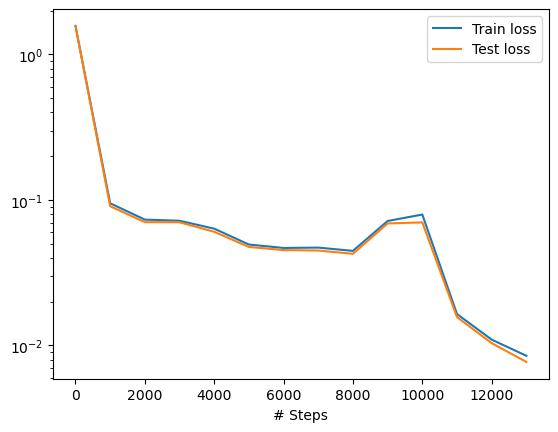

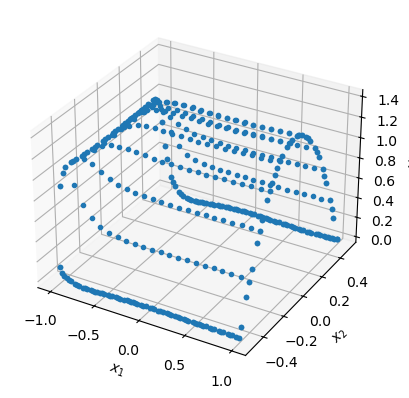

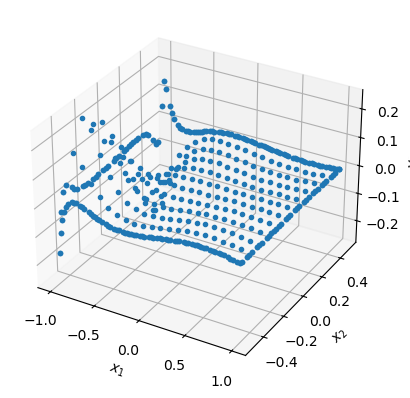

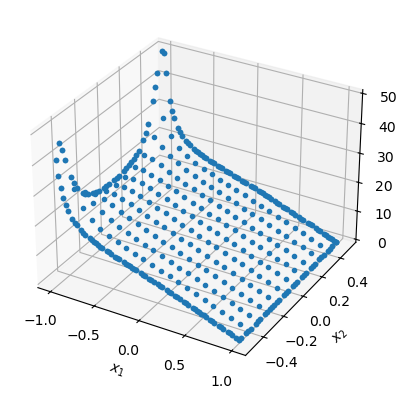

In [13]:
dde.saveplot(losshistory,train_state, issave= True, isplot=True)

In [14]:
samples = geom.random_points(500000)
result = model.predict(samples)

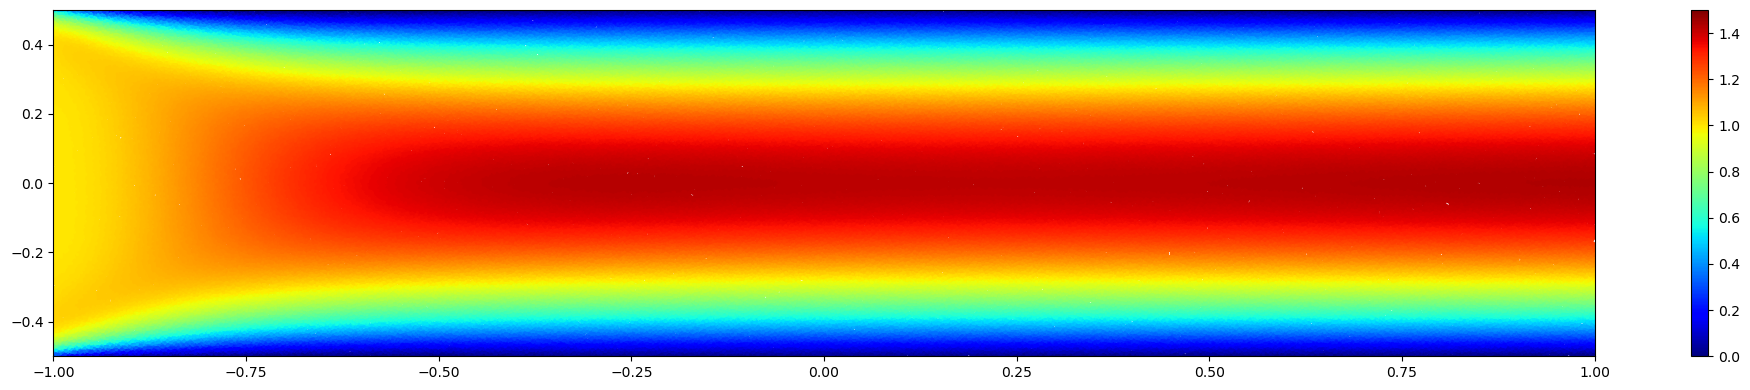

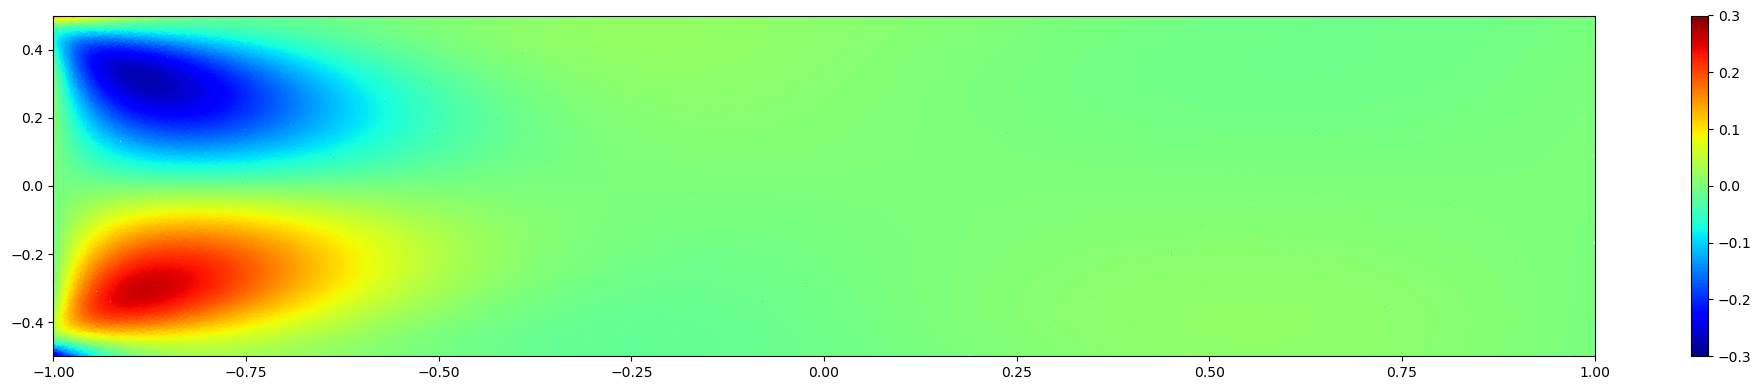

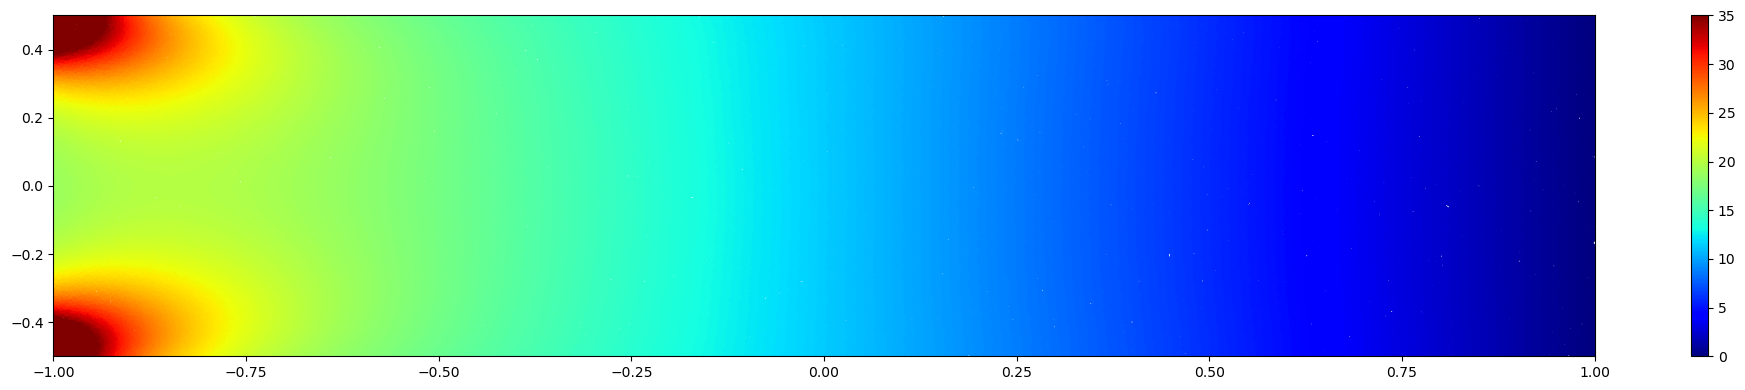

In [15]:
color_legend = [[0,1.5],[-0.3,0.3],[0,35]]

for idx in range(3):
    plt.figure(figsize=(20,4))
    plt.scatter(samples[:,0],
               samples[:,1],
               c = result[:,idx],
               cmap= 'jet',
               s=2)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((0-L/2, L-L/2))
    plt.ylim((0-D/2, D-D/2))
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# 1. Define Particle & Fluid Properties
# ==========================================
# Ensure these match your simulation units (non-dimensional or physical)
# Values below are placeholders; update them for your specific case.
FLUID_RHO = 1.0       # rho_g (Fluid Density)
FLUID_MU  = 1.0       # mu_g (Fluid Viscosity)
PARTICLE_D = 0.01     # d_p (Particle Diameter)
PARTICLE_RHO = 10.0   # rho_p (Particle Density)

# Derived Properties
PARTICLE_A = np.pi * (PARTICLE_D / 2)**2            # Cross-sectional Area (A_p)
PARTICLE_MASS = PARTICLE_RHO * (4/3) * np.pi * (PARTICLE_D / 2)**3  # Mass (m_p)

In [ ]:
# ==========================================
# 2. Define Physics Functions
# ==========================================

def get_drag_coefficient(Re):
    """
    Calculates Drag Coefficient (Cd) based on Reynolds number (Re).
    Uses standard Schiller-Naumann correlation.
    """
    if Re <= 0: return 0.0
    if Re < 1000:
        return (24.0 / Re) * (1 + 0.15 * (Re**0.687))
    return 0.44

def particle_momentum_eq(t, state, model):
    """
    Lagrangian Particle Momentum Equation (Drag Only).
    Equation 3 from provided PDF:
    m_p * dv_p/dt = 0.5 * C_D * A_p * rho_g * |v_p - v_g| * (v_g - v_p)
    """
    # Unpack state: position (x, y) and particle velocity (u_p, v_p)
    xp, yp, up, vp = state
    
    # --- A. Query DeepXDE Model for Fluid Velocity ---
    # Prepare input for prediction: shape (1, 2)
    pos_tensor = np.array([[xp, yp]])
    
    # Predict fluid variables [u, v, p] at particle position
    # Note: Ensure your trained model outputs align with indices [0, 1] for u, v
    fluid_vars = model.predict(pos_tensor)
    ug = fluid_vars[0, 0] # Fluid velocity u
    vg = fluid_vars[0, 1] # Fluid velocity v
    
    # --- B. Calculate Relative Velocity ---
    u_rel = ug - up
    v_rel = vg - vp
    v_rel_mag = np.sqrt(u_rel**2 + v_rel**2)
    
    # --- C. Calculate Particle Reynolds Number ---
    # Re_p = (rho_g * |v_rel| * d_p) / mu_g
    Re_p = (FLUID_RHO * v_rel_mag * PARTICLE_D) / FLUID_MU
    
    # --- D. Calculate Drag Force & Acceleration ---
    Cd = get_drag_coefficient(Re_p)
    
    # Acceleration = Force / Mass
    # F = 0.5 * Cd * A_p * rho_g * |v_rel| * v_rel
    # a = F / m_p
    coeff = (0.5 * Cd * PARTICLE_A * FLUID_RHO * v_rel_mag) / PARTICLE_MASS
    
    ax = coeff * u_rel
    ay = coeff * v_rel
    
    # Return derivatives [dx/dt, dy/dt, du_p/dt, dv_p/dt]
    return [up, vp, ax, ay]

In [ ]:
# ==========================================
# 3. Perform Particle Tracing
# ==========================================

def trace_particle(trained_model, t_max=5.0, steps=100):
    """
    Integrates the particle trajectory.
    """
    # Initial Conditions: [x0, y0, u_p0, v_p0]
    # Example: Start at inlet (-L/2, 0) with zero velocity
    y0 = [-1.0, 0.05, 0.0, 0.0] 
    
    t_span = [0, t_max]
    
    # Solve ODE using Runge-Kutta method (RK45)
    sol = solve_ivp(
        fun=particle_momentum_eq,
        t_span=t_span,
        y0=y0,
        args=(trained_model,), # Pass the trained DeepXDE model
        rtol=1e-5,
        atol=1e-7,
        dense_output=True
    )
    
    return sol

In [ ]:
# ==========================================
# 4. Usage Example
# ==========================================
# Assuming 'model' is your trained dde.Model object:
particle_sol = trace_particle(model)
#
# # Plotting
plt.figure(figsize=(10, 4))
plt.plot(particle_sol.y[0], particle_sol.y[1], 'r-', label='Particle Trajectory')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lagrangian Particle Tracking (Drag Only)')
plt.legend()
plt.grid(True)
plt.show()